## Analysis of EuRepoC Reported Cyber Incidents 
# Goal is to use NLP and machine learning to predict target countries of cyber attacks
Dataset: eurepoc_dyadic_dataset_0_1.csv

Which latent types of cyber operations emerge from incident descriptions, and how do these topics differ in intensity, impact, and political response? Are geopolitical cyber-conflict topics (Russia-Ukraine, Iran-Israel, China/APT, North Korea) associated with systematically different intensity levels and political responses?

1. Clean attack descriptions
2. Generate sentence embeddings (Sentence-BERT)
3. Topic modeling (BERTopic)
4. Topic discovery
5. Relationship with weighted intensity


Old Idea 1: Map the evolution of state-sponsord cyber operations from 2000-2024 using BERTopic and transformer embeddings.

1. Clean attack descriptions
2. generate sentence embeddings (Sentence-BERT)
3. Topic modeling (BERTopic)
4. Extract countries and organizations (spaCy)
5. Track topics over time
6. Build attack-type classifier
7. Visualize geopolitical networks

Old Idea 2: Predict receiver country based on initiating country, operation type, source disclosure (reported by whom), data theft, disruption, hijacking, ransomware, doxxing, physical effects (spatial, temporal), weighted cyber intensity (higher weightings for politically motivated attacks), impact indicator (sum of individual impact scores), political impact, intelligence impact, economic impact, number political responses, number legal responses

In [159]:
import pandas as pd
import html
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sklearn.feature_extraction.text import CountVectorizer
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from umap import UMAP
import random
import numpy as np
import spacy
from src.nlp_functions import(remove_geo_entities)
from scipy.stats import kruskal
import scikit_posthocs as sp

# Reproducibility 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [160]:
# Read in data 
url = "https://zenodo.org/records/14965395/files/eurepoc_dyadic_dataset_0_1.csv?download=1"

dyadic_data_full = pd.read_csv(url)

print(dyadic_data_full.shape)
print(dyadic_data_full.head())

(4296, 57)
   dyad_id initiator_country initiator_alpha_2 receiver_country  \
0        0       Afghanistan                AF      Afghanistan   
1        1       Afghanistan                AF         Pakistan   
2        1       Afghanistan                AF         Pakistan   
3        2           Algeria                DZ          Algeria   
4        2           Algeria                DZ          Algeria   

  receiver_country_alpha_2_code  incident_id  \
0                            AF         4278   
1                            PK          488   
2                            PK          499   
3                            DZ          525   
4                            DZ         1183   

                                                name  \
0  TalibLeaks Hacked and Leaked Documents from Ta...   
1               Afghan Cyber Army attack on Pakistan   
2       Afghan Cyber Army attack on Pakistan Part II   
3            Over-X vs. Algerian ministry of housing   
4               N

In [161]:
vars_to_check = [
    "impact_indicator_score",
    "weighted_intensity",
    "unweighted_intensity",
    "economic_impact",
    "functional_impact",
    "intelligence_impact"
]

for var in vars_to_check:
    print(f"\n{'='*60}")
    print(f"Value counts for: {var}")
    print(f"{'='*60}")
    print(dyadic_data_full[var].value_counts(dropna=False).sort_index())


Value counts for: impact_indicator_score
impact_indicator_score
0     2002
1       10
2       11
3       25
4       47
5      384
6      609
7      467
8      255
9      279
10     102
11      59
12      18
13      20
14       6
15       2
Name: count, dtype: int64

Value counts for: weighted_intensity
weighted_intensity
0      125
1     1284
2      594
3     1294
4      751
5      146
6       91
7        1
8        4
9        5
11       1
Name: count, dtype: int64

Value counts for: unweighted_intensity
unweighted_intensity
0     103
1    1296
2     600
3    1288
4     793
5     147
6      68
7       1
Name: count, dtype: int64

Value counts for: economic_impact
economic_impact
=< 10 Mio               56
> 10 Mio - 100 Mio      31
> 100 Mio - 1 bn         5
Not available         4204
Name: count, dtype: int64

Value counts for: functional_impact
functional_impact
Day (< 24h)                           273
Days (< 7 days)                       405
Months                                

In [162]:
# Isolate columns of interest
drop_vars = ["added_to_db","updated_at","attribution_id",\
    "initiator_alpha_2","receiver_country_alpha_2_code",
    "Data theft","Data theft & Doxing","Disruption",
    "Hijacking with Misuse","Hijacking without Misuse",
    "Ransomware","Not available"]

attack_labels = ["Data theft","Data theft & Doxing", \
    "Disruption","Hijacking with Misuse","Hijacking without Misuse",
    "Ransomware","Not available"]
attack_data = dyadic_data_full[["incident_id"] + attack_labels].copy()

dyadic_data = dyadic_data_full.drop(columns=drop_vars,\
    errors="ignore")

print(f"Original shape: {dyadic_data_full.shape}")
print(f"New shape: {dyadic_data.shape}")

print("\nRemaining columns:")
print(dyadic_data.columns.tolist())


Original shape: (4296, 57)
New shape: (4296, 45)

Remaining columns:
['dyad_id', 'initiator_country', 'receiver_country', 'incident_id', 'name', 'description', 'start_date', 'end_date', 'source_disclosure', 'operation_type', 'impact_indicator_score', 'impact_indicator_label', 'unweighted_intensity', 'weighted_intensity', 'number_attributions', 'number_political_responses', 'number_legal_responses', 'casualties', 'initiator_name', 'initiator_category', 'initiator_subcategory', 'receiver_id', 'receiver_name', 'receiver_category', 'receiver_subcategory', 'receiver_regions', 'offline_conflict_issue', 'offline_conflict_name', 'offline_conflict_intensity', 'offline_conflict_intensity_subcode', 'cyber_conflict_issue', 'physical_effects_spatial', 'physical_effects_temporal', 'target_multiplier', 'functional_impact', 'intelligence_impact', 'economic_impact', 'economic_impact_value', 'economic_impact_currency', 'affected_entities', 'affected_entities_value', 'affected_eu_countries', 'affected_eu

In [163]:
# Check for missing values in descriptions
print(dyadic_data["description"].isnull().sum())
print(dyadic_data[dyadic_data["description"]==""])

0
Empty DataFrame
Columns: [dyad_id, initiator_country, receiver_country, incident_id, name, description, start_date, end_date, source_disclosure, operation_type, impact_indicator_score, impact_indicator_label, unweighted_intensity, weighted_intensity, number_attributions, number_political_responses, number_legal_responses, casualties, initiator_name, initiator_category, initiator_subcategory, receiver_id, receiver_name, receiver_category, receiver_subcategory, receiver_regions, offline_conflict_issue, offline_conflict_name, offline_conflict_intensity, offline_conflict_intensity_subcode, cyber_conflict_issue, physical_effects_spatial, physical_effects_temporal, target_multiplier, functional_impact, intelligence_impact, economic_impact, economic_impact_value, economic_impact_currency, affected_entities, affected_entities_value, affected_eu_countries, affected_eu_countries_value, affected_third_countries, affected_third_countries_value]
Index: []

[0 rows x 45 columns]


In [164]:
# Incident-level dataset for NLP
# Descriptions can be duplicated because of the dyadic nature of the dataset. 
# One incident may span several rows if it affected several countries. 
incident_text_data = (
    dyadic_data
    .drop_duplicates(subset=["incident_id"])
    .copy()
)
print(incident_text_data.head())


   dyad_id initiator_country receiver_country  incident_id  \
0        0       Afghanistan      Afghanistan         4278   
1        1       Afghanistan         Pakistan          488   
2        1       Afghanistan         Pakistan          499   
3        2           Algeria          Algeria          525   
4        2           Algeria          Algeria         1183   

                                                name  \
0  TalibLeaks Hacked and Leaked Documents from Ta...   
1               Afghan Cyber Army attack on Pakistan   
2       Afghan Cyber Army attack on Pakistan Part II   
3            Over-X vs. Algerian ministry of housing   
4               North African Fox Espionage campaign   

                                         description           start_date  \
0  On 7 February 2025, a group of hackers, callin...  2024-01-01 00:00:00   
1  Afghan hackers deface six Pakistani government...  2013-07-11 00:00:00   
2  Afghan hackers hack the webpage of the Pakista...  2013-

In [165]:
# Clean description
incident_text_data["description"] = (
    incident_text_data["description"] 
    .fillna("")
    .astype(str)
    .apply(html.unescape)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [166]:
# Identify missing descriptions
print(incident_text_data["description"].isna().sum())

# Empty descriptions
print((incident_text_data["description"] == "").sum())

# Length distribution
incident_text_data["n_words"] = (
    incident_text_data["description"]
    .str.split()
    .str.len()
)

print(incident_text_data["n_words"].describe())

incident_text_data.loc[
    incident_text_data["n_words"] < 5,
    ["incident_id", "description"]
].head(20)


0
0
count    2957.000000
mean       80.144065
std        69.850175
min         3.000000
25%        29.000000
50%        65.000000
75%       112.000000
max       975.000000
Name: n_words, dtype: float64


,incident_id,description
1366,361,Taliban website hacked
2433,370,Israeli Government Site Hacked
4058,358,The Unknowns' hack NASA


In [167]:
# Check how many short descriptions would be lost if filtered out
print((incident_text_data["n_words"] < 5).sum())
print((incident_text_data["n_words"] < 10).sum())

3
105


In [168]:
# Filter out descriptions with less than five words
incident_text_data = incident_text_data[incident_text_data["n_words"] > 5]

In [169]:
# Remove geographic terms from text
nlp = spacy.load("en_core_web_sm")

incident_text_data["description_no_geo"] = (
    incident_text_data["description"]
    .apply(lambda x: remove_geo_entities(x, nlp))
)

In [170]:
# Sentence embeddings with BERT
model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

embeddings = model.encode(
    incident_text_data["description_no_geo"].tolist(),
    show_progress_bar=True
)

Batches: 100%|██████████| 92/92 [00:02<00:00, 43.79it/s]


In [171]:
# Generic stopwords 
cyber_stopwords = [
    "attack",
    "attacks",
    "attacker",
    "hack",
    "hacks",
    "hacked",
    "hacker",
    "hackers",
    "hacking",
    "campaign",
    "group",
    "security",
    "incident",
    "reported",
    "report",
    "unknown"
]

vectorizer_model = CountVectorizer(
    stop_words=cyber_stopwords,
    min_df=5,
    ngram_range=(1, 3)
)

In [ ]:
# Get rid of stopwords, BERT wasn't using them effectively
#vectorizer_model = CountVectorizer(
#    stop_words="english",
#    min_df=5,
#    ngram_range=(1, 3)
#)

# BERTopic analysis 
# For reproducibility 
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
) 

# For more readable labels
representation_model = KeyBERTInspired()


# Build topic model 
topic_model = BERTopic(
    embedding_model=model,
    umap_model=umap_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    min_topic_size=20,
    calculate_probabilities=True
)


topics, probs = topic_model.fit_transform(
    incident_text_data["description_no_geo"],
    embeddings
)

topic_model = topic_model.reduce_topics(
    incident_text_data["description_no_geo"],
    nr_topics=10
)

topics = topic_model.topics_

incident_text_data["topic"] = topics
incident_text_data["topic_prob"] = probs.max(axis=1)

In [198]:
# Save model 
topic_model.save("eurepoc_final_model")

incident_text_data[
    ["incident_id", "topic", "topic_prob"]
].to_csv(
    "eurepoc_topic_assignments.csv",
    index=False
) 

topic_model.get_topic_info().to_csv(
    "topic_info.csv",
    index=False
)

2026-08-19 13:44:13,626 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


In [173]:
# Examine topics
topic_info = topic_model.get_topic_info()
#print(topic_info.head())

topic_info[["Topic", "Count", "Representation"]]\
    .style.set_table_attributes(
        'style="display:block;max-height:500px;overflow:auto;"'
    )

,Topic,Count,Representation
0,-1,1333,"['ransomware', 'compromised', 'threat', 'cyber', 'stolen', 'operation', 'gained access to', 'government', 'gained access', 'data']"
1,0,420,"['the government', 'attacked', 'gov', 'website of the', 'sites', 'cyber', 'website', 'government', 'site', 'anonymous']"
2,1,286,"['malware', 'the malware', 'cyber espionage', 'vulnerabilities', 'malicious', 'compromised', 'threat actors', 'vulnerability', 'espionage', 'threat']"
3,2,211,"['the ransomware', 'ransomware', 'ransom', 'compromised', 'encrypted', 'breach', 'stolen', 'investigation', 'access', 'services']"
4,3,191,"['ddos', 'with ddos', 'hacktivist', 'cyber', 'targeted', 'disrupted', 'disruption', 'disrupted the', 'authorities', 'telegram']"
5,4,189,"['data breach', 'stolen data', 'personal data', 'breached', 'personal information', 'breach', 'compromised', 'the breach', 'data', 'the data']"
6,5,186,"['ransomware', 'cyberattack', 'compromised', 'intrusion', 'the university', 'university of', 'university', 'gained access to', 'investigation', 'gained access']"
7,6,70,"['exploited vulnerability', 'the theft of', 'exploited', 'theft', 'theft of', 'the theft', 'exploit', 'vulnerability in', 'vulnerability', 'stole']"
8,7,28,"['espionage', 'the investigation', 'investigation', 'suspected', 'forensic', 'human rights', 'device', 'devices', 'the phone', 'phones']"
9,8,28,"['malware', 'the malware', 'the nsa', 'espionage', 'nsa', 'cyber', 'backdoor', 'attackers', 'secure', 'infected']"


In [174]:
# Load pre-saved model
#topic_model = BERTopic.load("eurepoc_final_model")

# Add topic info to deduplicated dataset
incident_text_data["topic"] = topic_model.topics_
incident_text_data["topic_prob"] = probs.max(axis=1)

# Create a look-up table
topic_lookup = incident_text_data[
    ["incident_id", "topic"]
].copy()

# Create interpretable topic labels
topic_info = topic_model.get_topic_info()

topic_labels = (
    topic_info[["Topic", "Representation"]]
    .copy()
)

topic_labels["topic_label"] = (
    topic_labels["Representation"]
    .apply(lambda x: ", ".join(x[:5]))
)

# Merge topics onto dyadic data
dyadic_data = dyadic_data_full.drop(
    columns=drop_vars,
    errors="ignore"
).copy()

dyadic_data = dyadic_data.merge(
    topic_lookup,
    on="incident_id",
    how="left"
)

dyadic_data = dyadic_data.merge(
    topic_labels[["Topic", "topic_label"]],
    left_on="topic",
    right_on="Topic",
    how="left"
)

dyadic_data = dyadic_data.dropna(
    subset=["topic"]
).copy()

print(dyadic_data["topic"].isna().sum())
print(dyadic_data["topic"].value_counts().head())


0
topic
-1.0    2035
 1.0     748
 0.0     478
 2.0     233
 3.0     202
Name: count, dtype: int64


In [175]:
print(
    dyadic_data[
        ["topic", "topic_label"]
    ].drop_duplicates()
    .sort_values("topic")
)

      topic                                        topic_label
0      -1.0     ransomware, compromised, threat, cyber, stolen
1       0.0  the government, attacked, gov, website of the,...
112     1.0  malware, the malware, cyber espionage, vulnera...
11      2.0  the ransomware, ransomware, ransom, compromise...
97      3.0       ddos, with ddos, hacktivist, cyber, targeted
426     4.0  data breach, stolen data, personal data, breac...
1087    5.0  ransomware, cyberattack, compromised, intrusio...
1119    6.0  exploited vulnerability, the theft of, exploit...
41      7.0  espionage, the investigation, investigation, s...
71      8.0      malware, the malware, the nsa, espionage, nsa


In [176]:
# Remove outliers
dyadic_data = dyadic_data[
    dyadic_data["topic"] != -1
].copy()

In [ ]:
# Create more readable topic names from topic labels
topic_names = {
    -1: "General Cyber Operations",
     0: "Website Defacement & Hacktivism",
     1: "Malware & Cyber Espionage",
     2: "Ransomware & Cyber Extortion",
     3: "DDoS & Service Disruption Campaigns",
     4: "Data Breaches & Information Exposure",
     5: "Institutional Ransomware Attacks",
     6: "Vulnerability Exploitation & Theft",
     7: "Surveillance & Mobile Espionage",
     8: "Government Intelligence Operations"
} 

dyadic_data["topic_name"] = (
    dyadic_data["topic"]
    .map(topic_names)
)

topic_groups = {
    # Hacktivism
    "Website Defacement & Hacktivism":
        "Hacktivism",

    # Disruption
    "DDoS & Service Disruption Campaigns":
        "Disruption Operations",

    # Intrusion
    "Malware & Cyber Espionage":
        "Intrusion Operations",

    "Vulnerability Exploitation & Theft":
        "Intrusion Operations",

    # Information
    "Surveillance & Mobile Espionage":
        "Information Operations",

    "Government Intelligence Operations":
        "Information Operations",

    # Data exposure
    "Data Breaches & Information Exposure":
        "Data Exposure",

    # Financial
    "Ransomware & Cyber Extortion":
        "Financially Motivated Operations",

    "Institutional Ransomware Attacks":
        "Financially Motivated Operations",

    # Catch-all
    "General Cyber Operations":
        "Other"
}

dyadic_data["topic_group"] = (
    dyadic_data["topic_name"]
    .map(topic_groups)
)

print(
    dyadic_data[
        ["topic", "topic_name", "topic_group"]
    ]
    .drop_duplicates()
    .sort_values("topic")
)

print("\nMissing topic names:")
print(dyadic_data["topic_name"].isna().sum())

print("\nMissing topic groups:")
print(dyadic_data["topic_group"].isna().sum())


      topic                            topic_name  \
1       0.0       Website Defacement & Hacktivism   
112     1.0             Malware & Cyber Espionage   
11      2.0          Ransomware & Cyber Extortion   
97      3.0   DDoS & Service Disruption Campaigns   
426     4.0  Data Breaches & Information Exposure   
1087    5.0      Institutional Ransomware Attacks   
1119    6.0    Vulnerability Exploitation & Theft   
41      7.0       Surveillance & Mobile Espionage   
71      8.0    Government Intelligence Operations   

                           topic_group  
1                           Hacktivism  
112               Intrusion Operations  
11    Financially Motivated Operations  
97               Disruption Operations  
426                      Data Exposure  
1087  Financially Motivated Operations  
1119              Intrusion Operations  
41              Information Operations  
71              Information Operations  

Missing topic names:
0

Missing topic groups:
0


In [178]:
# Topic vs intensity
dyadic_data.groupby("topic_group")["weighted_intensity"]\
    .mean()\
    .sort_values(ascending=False)

topic_group
Intrusion Operations                3.756458
Financially Motivated Operations    3.227154
Information Operations              2.887640
Data Exposure                       2.568182
Hacktivism                          1.405858
Disruption Operations               1.389892
Name: weighted_intensity, dtype: float64

In [179]:
# Topic vs political responses
dyadic_data.groupby("topic_group")["number_political_responses"]\
    .mean()\
    .sort_values(ascending=False)

topic_group
Disruption Operations               0.220217
Intrusion Operations                0.147601
Data Exposure                       0.145722
Financially Motivated Operations    0.109661
Hacktivism                          0.008368
Information Operations              0.000000
Name: number_political_responses, dtype: float64

In [180]:
# Most common receiver countries by topic
pd.crosstab(
    dyadic_data["receiver_country"],
    dyadic_data["topic_group"]
)

topic_group,Data Exposure,Disruption Operations,Financially Motivated Operations,Hacktivism,Information Operations,Intrusion Operations
receiver_country,,,,,,
Afghanistan,11,0,0,3,2,0
Africa,5,1,0,0,1,0
Albania,1,0,0,1,0,0
Algeria,0,0,0,1,0,0
Angola,0,0,1,1,0,0
...,...,...,...,...,...,...
Venezuela,1,0,0,5,0,1
Vietnam,18,0,0,2,2,2
Western Europe,4,0,0,0,0,0


## Visualizations

In [181]:
# What cyber conflict themes dominate the dataset?
topic_counts = (
    dyadic_data["topic_group"]
    .value_counts()
    .reset_index()
)

topic_counts.columns = ["topic", "count"]

fig = px.treemap(
    topic_counts,
    path=["topic"],
    values="count",
    title="Distribution of Cyber Conflict Topics"
)

fig.show()

fig.write_html("topic_treemap.html")

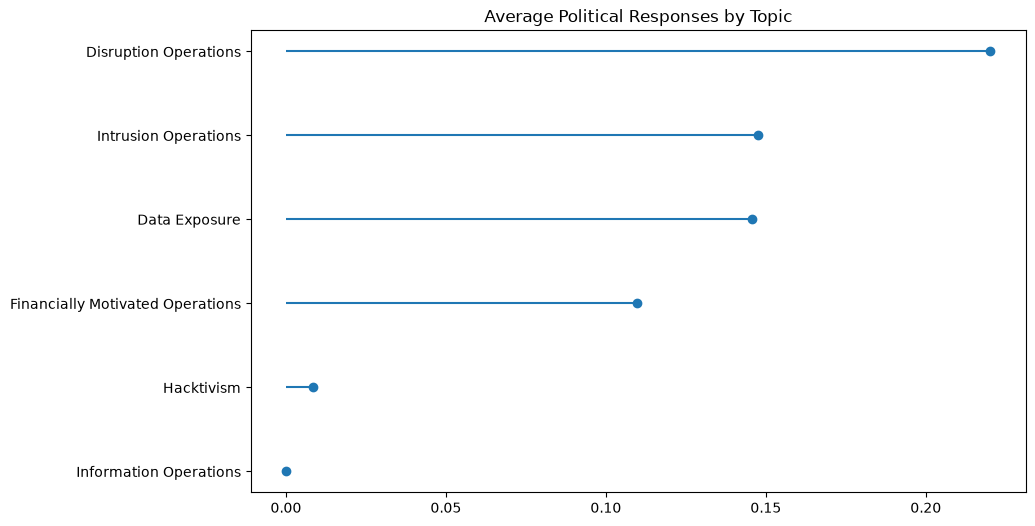

In [182]:
# What cyber conflicts trigger political reactions?
responses = (
    dyadic_data.groupby("topic_group")
    ["number_political_responses"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))

plt.hlines(
    y=responses.index,
    xmin=0,
    xmax=responses.values
)

plt.plot(
    responses.values,
    responses.index,
    "o"
)

plt.title("Average Political Responses by Topic")
plt.show()

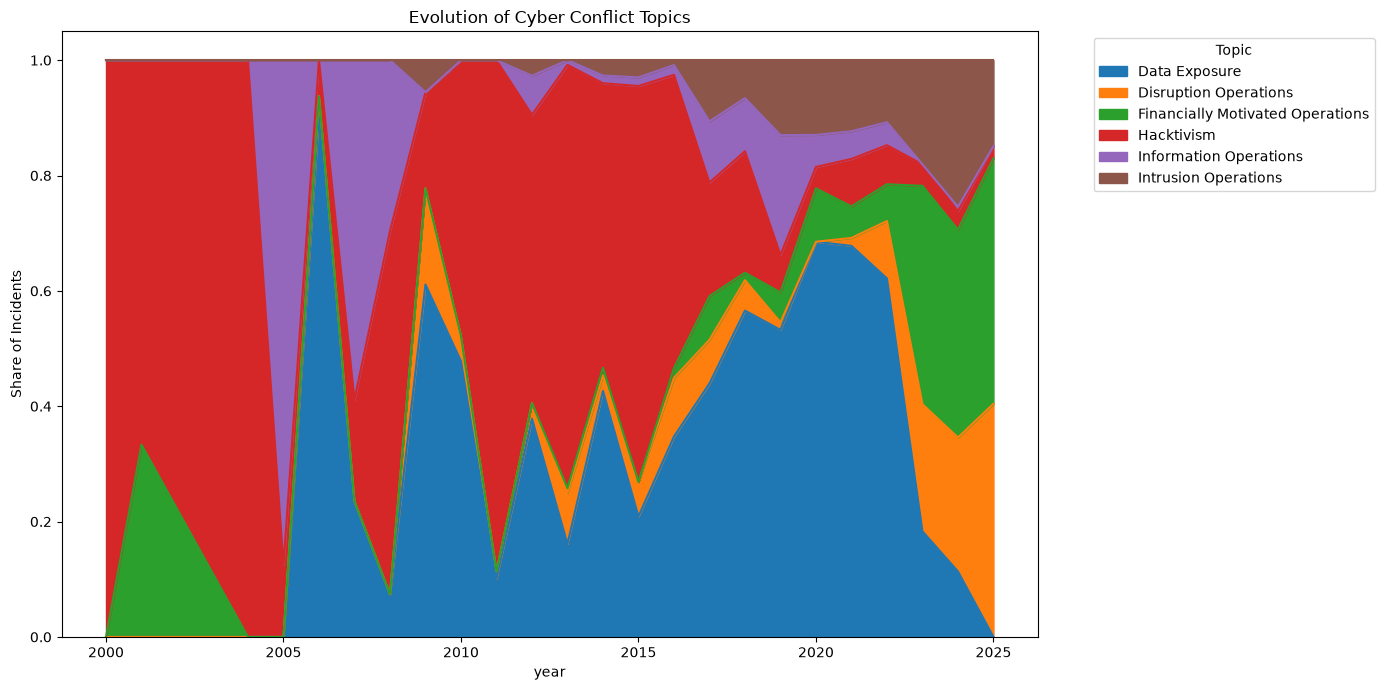

In [183]:
# How has the nature of cyber conflict changed over time?
dyadic_data["year"] = pd.to_datetime(
    dyadic_data["start_date"],
    errors="coerce"   # invalid dates become NaT
).dt.year

topic_year = pd.crosstab(
    dyadic_data["year"],
    dyadic_data["topic_group"],
    normalize="index"
)

fig, ax = plt.subplots(figsize=(14, 7))

topic_year.plot.area(ax=ax)

ax.set_title("Evolution of Cyber Conflict Topics")
ax.set_ylabel("Share of Incidents")

ax.legend(
    title="Topic",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


## Analysis 

The primary goal of this analysis is to investigate what latent categories of cyber operations emerge form inicident descriptions, and answer how these categories are associated with different initiator countries, target countries, and political outcomes. 

Q1: What operational patterns connect initiator countries, cyber operation types, and receiver countries?
- Visualization: Sankey plot 

Q2: Which operational categories are associated with the most severe incidents?
- Visualization: Boxplot of weighted_intenity
- Statistical Test: Kruskal-Wallis

Q3: What types of cyber operations provoke political responses?
- Visualization: Hline plot

Q4: How have trends in cyber operations evolved over time?
- Visualizaiton: Stacked area chart 

Q5: Which countries are targeted by which types of cyber operations?
- Visualization: Reciever specialization heatmap

Q6: What cyber operation themes dominate the dataset?
- Visualization: Treemap


### Q1: What operational patterns connect initiator countries, cyber operation types, and receiver countries?

In [184]:
# Filters for sankey visual
top_initiators = (
    dyadic_data["initiator_country"]
    .value_counts()
    .head(10)
    .index
)

top_receivers = (
    dyadic_data["receiver_country"]
    .value_counts()
    .head(10)
    .index
)

sankey_data = dyadic_data[
    dyadic_data["initiator_country"].isin(top_initiators)
    &
    dyadic_data["receiver_country"].isin(top_receivers)
].copy()

In [185]:
# Shorten topic labels
sankey_data["short_topic"] = (
    sankey_data["topic_group"]
    .str.split(",")
    .str[:3]
    .str.join(", ")
)

In [186]:
# Create flows
# Initiator -> Topic
flow1 = (
    sankey_data
    .groupby(
        ["initiator_country", "short_topic"]
    )
    .size()
    .reset_index(name="value")
)

# Topic -> Reciever
flow2 = (
    sankey_data
    .groupby(
        ["short_topic", "receiver_country"]
    )
    .size()
    .reset_index(name="value")
)

In [187]:
# Build node list
nodes = list(
    pd.concat([
        flow1["initiator_country"],
        flow1["short_topic"],
        flow2["receiver_country"]
    ]).unique()
)

node_dict = {
    node: i
    for i, node in enumerate(nodes)
}

In [188]:
# Build link table
source = []
target = []
value = []

# Initiator -> Topic
for _, row in flow1.iterrows():
    source.append(
        node_dict[row["initiator_country"]]
    )
    target.append(
        node_dict[row["short_topic"]]
    )
    value.append(row["value"])

# Topic -> Receiver
for _, row in flow2.iterrows():
    source.append(
        node_dict[row["short_topic"]]
    )
    target.append(
        node_dict[row["receiver_country"]]
    )
    value.append(row["value"])

In [189]:
fig = go.Figure(
    go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            label=nodes
        ),
        link=dict(
            source=source,
            target=target,
            value=value
        )
    )
)

fig.update_layout(
    title="Cyber Conflict Flows: Initiator → Topic → Receiver",
    font_size=10
)

fig.write_html("cyber_conflict_sankey.html")

fig.show()


The Sankey plot visualizes the flow of cyber incidents from initiating actors to operational categories and finally to recipient countries. The width of each flow is proportional to the number of incidents observed in the dataset. Cyber incidents are first groupd by initiator country, then aggregated into five broad operational categories derived from BERTopic analysis: **Financially Motivated Operations, Intrusions, Disruption Operations, Information Operations, Data Breaches (General), and Data Breaches (Healthcare)**. The final stage shows the principal recipient coutnries associated with each operational category. 

**Key Findings**
1. **Financially Motivated operations constitute the largest category of incidents**, indicating that ransomware and extortion-related activities are among the most prevalent forms of cyber conflict represented in the dataset.
2. **Intrusion opeerations form a second major cluster**, capturing incidents involving malware deployment, unauthorized access, and exploitation of vulnerabilities.
3. **The US is the largest recipient node**, receiving substantial flows across multiple operational categories, particularily financially motivated attacks, intrusions, and data exposure operations. 
4. **Attribution remains a major challenge in cyber conflict**, as "Not Attributed" and "Unkknown" represent some of the largest initiating categories in the diagram.
5. **State actors exhibit different operational profiles**. For example, China appears more closely associated with intrusion-oriented operations, while Russia's activity is distributed across intrusion, disruption, and information-related operations. 

# Q2: Which operational categories are associated with the most impactful incidents?

In [190]:
topic_summary = (
    dyadic_data
    .groupby("topic_group")
    .agg(
        incidents=("incident_id", "count"),
        avg_intensity=("weighted_intensity", "mean"),
        avg_political=("number_political_responses", "mean"),
        avg_legal=("number_legal_responses", "mean")
    )
    .round(2)
)

print(topic_summary)

                                  incidents  avg_intensity  avg_political  \
topic_group                                                                 
Data Exposure                           748           2.57           0.15   
Disruption Operations                   277           1.39           0.22   
Financially Motivated Operations        383           3.23           0.11   
Hacktivism                              478           1.41           0.01   
Information Operations                   89           2.89           0.00   
Intrusion Operations                    271           3.76           0.15   

                                  avg_legal  
topic_group                                  
Data Exposure                          0.02  
Disruption Operations                  0.11  
Financially Motivated Operations       0.34  
Hacktivism                             0.02  
Information Operations                 0.00  
Intrusion Operations                   0.36  


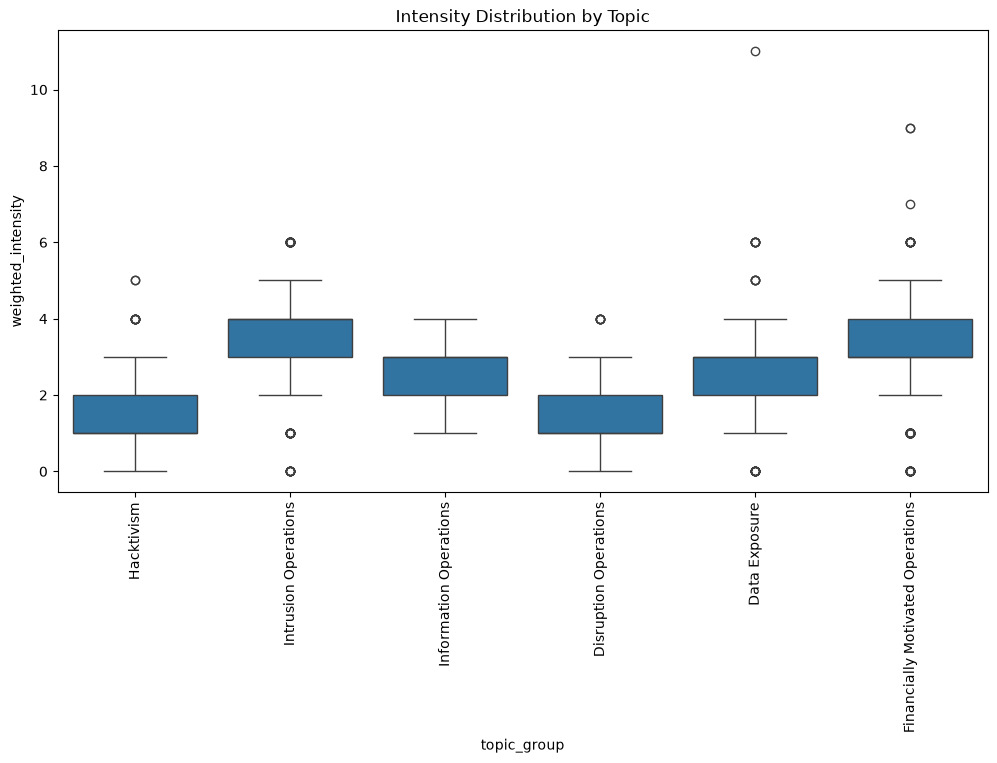

In [191]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=dyadic_data,
    x="topic_group",
    y="weighted_intensity"
)

plt.xticks(rotation=90)
plt.title("Intensity Distribution by Topic")
plt.show()

Kruskal-Wallis test for significant differences between operation types

In [192]:
# First drop duplicate incident_ids in the dataset
topic_analysis = (
    dyadic_data
    .drop_duplicates(subset=["incident_id"])
    .copy()
)

# Check sample sizes
print(
    dyadic_data.groupby("topic_group")
    .size()
    .sort_values(ascending=False)
)

# Run Kruskal-Wallis test
groups = [
    g["weighted_intensity"].dropna()
    for _, g in topic_analysis.groupby("topic_name")
]

stat, p = kruskal(*groups)

print(f"Kruskal-Wallis H-statistic: {stat:.3f}")
print(f"p-value: {p:.6f}")

alpha = 0.05

if p < alpha:
    print("Significant differences in weighted intensity across topics.")
else:
    print("No significant differences in weighted intensity across topics.")


topic_group
Data Exposure                       748
Hacktivism                          478
Financially Motivated Operations    383
Disruption Operations               277
Intrusion Operations                271
Information Operations               89
dtype: int64
Kruskal-Wallis H-statistic: 686.467
p-value: 0.000000
Significant differences in weighted intensity across topics.


In [193]:
sig = results_df.loc[results_df["Significant"]].copy()

sig["Comparison"] = (
    sig["Group 1"]
    + " vs "
    + sig["Group 2"]
)

print(
    sig[["Comparison", "p-value"]]
    .sort_values("Comparison")
    .to_string(index=False)
)

                                                Comparison       p-value
                         Credential Theft vs Data Exposure  3.496678e-07
      Credential Theft vs Financially Motivated Operations  7.273293e-21
                Credential Theft vs Information Operations  5.462586e-08
                  Credential Theft vs Intrusion Operations  2.073743e-05
                    Data Exposure vs Disruption Operations  1.380462e-20
         Data Exposure vs Financially Motivated Operations  2.268463e-13
                               Data Exposure vs Hacktivism  3.048169e-42
 Disruption Operations vs Financially Motivated Operations  6.938303e-71
                       Disruption Operations vs Hacktivism  5.988796e-03
           Disruption Operations vs Information Operations  7.779306e-22
             Disruption Operations vs Intrusion Operations  1.072306e-19
            Financially Motivated Operations vs Hacktivism 4.679624e-117
Financially Motivated Operations vs Information Ope

In [194]:
pd.crosstab(
    dyadic_data["receiver_country"],
    dyadic_data["topic_name"],
    normalize="index"
)

topic_name,Cyber Espionage Against Government Targets,DDoS & Hacktivist Campaigns,Data Breaches & Information Exposure,Institutional Ransomware Attacks,Malware Operations,Ransomware & Cyber Extortion,Service Disruption Operations,Vulnerability Exploitation & Theft,Website Defacement & Hacktivism
receiver_country,,,,,,,,,
Afghanistan,0.125000,0.0,0.687500,0.0,0.000000,0.0,0.000000,0.0,0.187500
Africa,0.142857,0.0,0.714286,0.0,0.000000,0.0,0.142857,0.0,0.000000
Albania,0.000000,0.0,0.500000,0.0,0.000000,0.0,0.000000,0.0,0.500000
Algeria,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,1.000000
Angola,0.000000,0.0,0.000000,0.5,0.000000,0.0,0.000000,0.0,0.500000
...,...,...,...,...,...,...,...,...,...
Venezuela,0.000000,0.0,0.142857,0.0,0.142857,0.0,0.000000,0.0,0.714286
Vietnam,0.083333,0.0,0.750000,0.0,0.083333,0.0,0.000000,0.0,0.083333
Western Europe,0.000000,0.0,1.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000


In [195]:
topic_analysis.loc[
    topic_analysis["topic_group"].isna(),
    ["topic_name"]
].drop_duplicates()

,topic_name
